# La ley de una variable aleatroria 

**Blanca Sánchez Germán**

*Sesión del 17/06/2026*


Sea el experimiento aletririo de lanzar un dado do veces (lazar dos daos ). Entonces se tienen $$\Omega = \{(i, j) \mid i, j \in \{1, 2, 3, 4, 5, 6\}\}$$

y sea el evento $S_n$: la suma de los dadod es $n$, es decir, 
$$ S_n = \{(i, j) \in \Omega \mid i + j = n\}$$

In [1]:
#Vamos a trabjar con fracciones
from fractions import Fraction

Vamos a definir la funcion de probabilidad que toma un evento $A$, y devuelve su probabilidad como fracción:

In [2]:
def P(A):
    P = Fraction (len (A),len (Omega))
    return P 

Vamos a crear el espacio muestral asociado a este experimiento aleatrio: 

In [3]:
from itertools import product 
Omega = set(product([1,2,3,4,5,6],repeat=2))

Creamos el evento $S_n$

In [8]:
#Asociamos a cada par de números 
Sn ={ (i,j) : i+j for i,j in Omega}
#Sn

Ahora vamos agrupar combinaciones por suma, para esto vamos a usar `defaultdict(set)` para crear un diccionario cuyas claves tengan como valor un conjunto vacío por defecto. 

**Nota:** Es útil cuando queremos agrupar resultados sin tener que verificar primero si la llave existees el diccionario.

In [9]:
# Agrupomos combinaciones por suma 
# Se crea un diccionaario que por defecto crea un conjunto vacio para cada nueva clave 
from collections import defaultdict
#Recorrer el diccionario S_n y agrupa por suma 
dSn = defaultdict(set)

In [14]:
#Vamos a recorrer los elementos del diccionario:
#pareja ordenarla y añadimos esa suma 
for i,j in Sn.items():
    dSn[j].add(i)

Lo anterior 'Sn.intens()´ sirve para recorrer simultaneamnete las llaves y los valores del  diccionario. En esta caso: 

- `i` es la clave, es decir, un par ordenado `(a,b)`
-  `j`es el valor asociado, es decir, la suma `a+b`
  
Luego, `dSn[j].add(i)` agrega el par el par `(a,b)` al conjunto corresponiente a la suma `j`

In [16]:
#Vamod a visualizar la lisra (suma, pares ordenados)
list(dSn.items()) # convertimos los elemntos en una lista 

[(7, {(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}),
 (4, {(1, 3), (2, 2), (3, 1)}),
 (9, {(3, 6), (4, 5), (5, 4), (6, 3)}),
 (10, {(4, 6), (5, 5), (6, 4)}),
 (6, {(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)}),
 (8, {(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)}),
 (11, {(5, 6), (6, 5)}),
 (3, {(1, 2), (2, 1)}),
 (5, {(1, 4), (2, 3), (3, 2), (4, 1)}),
 (2, {(1, 1)}),
 (12, {(6, 6)})]

## La densidad de la variable aletoria $S_n$

Recordemos que una variable  aletroria real $x$, es una función $X:\Omega\to\mathbb(R)$

Sabemos que la **ley de una variable aletoria discreta** $X$ (la densidad, función de masa de probabilidad), se define como sigue: 

$$ f_X(x)= \begin {cases}
\mathbb {P}(X=x), \quad\text{si} x\in R_x \\
\quad 0, \quad\text{e.o.c}
\end{cases}$$
donfr $R_X$ es el rango de la varibel aletraoria$X$.

Para nuestro evento $S_n$, se tien la siguiente variable aletaria: 


$$S_n : \Omega \rightarrow \{2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12\}$$

Vamos a crear la funcion de densidad de $S_n$, que será la probabilidad de cada suma:

In [18]:
#LeySn almacena la probabilidad de cada suma posible usando la funcion P(A)
# A represenra el conjunto de pares ordenados que producen la suma i
LeySn ={i : P(A) for i,A in dSn.items()}
LeySn

{7: Fraction(1, 6),
 4: Fraction(1, 12),
 9: Fraction(1, 9),
 10: Fraction(1, 12),
 6: Fraction(5, 36),
 8: Fraction(5, 36),
 11: Fraction(1, 18),
 3: Fraction(1, 18),
 5: Fraction(1, 9),
 2: Fraction(1, 36),
 12: Fraction(1, 36)}

Vamos a usar la libreria `pandas` que es útil para manipular y analizar datos en Python. Se utiliza la abreviatura `pd` para dacilicitar su uso


In [19]:
import pandas as pd

Vamos a usar `pd.Series()` para convertir el diccionario `LeySn` es una serie de pandas

In [21]:
#Nos daran las columnas de números y la asigancion de probabilidad en fracciones 
Ley_Sn = pd.Series(LeySn)
Ley_Sn

7      1/6
4     1/12
9      1/9
10    1/12
6     5/36
8     5/36
11    1/18
3     1/18
5      1/9
2     1/36
12    1/36
dtype: object

Vamos a ordenar la serie de manera ascendente por el índice

In [22]:
Ley_Sn =Ley_Sn.sort_index()
Ley_Sn

2     1/36
3     1/18
4     1/12
5      1/9
6     5/36
7      1/6
8     5/36
9      1/9
10    1/12
11    1/18
12    1/36
dtype: object

**Nota:** Si se quiere en orden descendente se utiliza **`Ley_Sn.sort_index(ascending-False)`**

**Definimso la función de densidad**

In [30]:
#LeyS(i) devuelve la probabilidad de obtenet la suma i, si esto en el rango de la v.a 

def LeyS(i):
    if i in range(2, 13): 
        x = LeySn[i] # Me asigna probabilidad
    else:
        x = 0 # No me asigne la probabilidad
        
    return x # Movido hacia la izquierda para que siempre retorne el valor

In [31]:
#Creamos el rango de la v.a Sn 
rango_S =[k for k in range(2,13)]

# Obtenemos la probabilidad de cada suma en el rango S 
p_k = [float(LeyS(k)) for k in rango_S]
p_k

[0.027777777777777776,
 0.05555555555555555,
 0.08333333333333333,
 0.1111111111111111,
 0.1388888888888889,
 0.16666666666666666,
 0.1388888888888889,
 0.1111111111111111,
 0.08333333333333333,
 0.05555555555555555,
 0.027777777777777776]

In [32]:
#Podemos verificar que la suma es 1 
sum(p_k)

1.0

Vamos a crear una DataFrame, donde  los valores del rango es S (`rango_S`) y `p_k` son la probabilidades de cada suma

In [33]:
lS = pd.DataFrame(list(zip(rango_S, p_k)), # zip sirve para emparejar elementos de dos listas
                  index = [f'S_{k}' for k in rango_S],
                  columns = ['rango', 'densidad'])
lS

,rango,densidad
S_2,2,0.027778
S_3,3,0.055556
S_4,4,0.083333
S_5,5,0.111111
S_6,6,0.138889
S_7,7,0.166667
S_8,8,0.138889
S_9,9,0.111111
S_10,10,0.083333
S_11,11,0.055556


<Axes: xlabel='rango'>

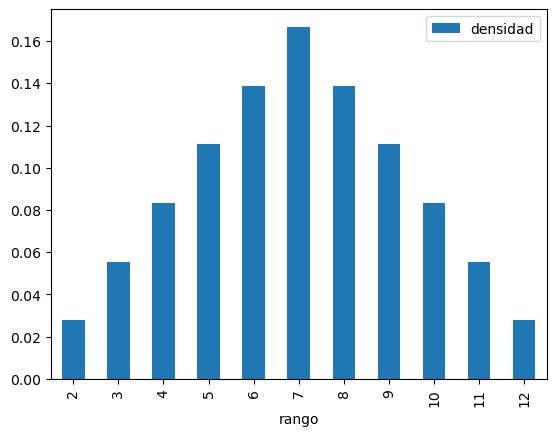

In [34]:
lS.plot.bar( x = 'rango', y ='densidad')